<a href="https://colab.research.google.com/github/xesmaze/CPSC499-MDV-SR25/blob/main/Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Glossary of Terms**

- **$Interpretability$**: The degree to which a human can understand the internal mechanics or decision processes of a model.

- **$Global\ Interpretability$**: Explanations that describe the overall behavior of the model across all inputs.

- **$Local\ Interpretability$**: Explanations that describe the model’s decision for a single input instance.

- **$Intrinsic\ Interpretability$**: Models or architectures designed from the ground up to be transparent (e.g., decision trees, attention mechanisms).

- **$Post\text{-}hoc\ Interpretability$**: Techniques applied after training a “black-box” model to explain its predictions.

- **$Saliency\ Map$**: A gradient-based visualization highlighting which input features (e.g., pixels) most influence the output.

- **$SmoothGrad$**: A variant of saliency maps that averages gradients over noisy copies of the input to reduce visual noise.

- **$Integrated\ Gradients$**: A method that accumulates gradients along a path from a baseline input to the actual input to attribute features more robustly.

- **$LIME$** (Local Interpretable Model-agnostic Explanations): Approximates the model locally around a prediction with a simple, interpretable surrogate (e.g., linear model).

- **$SHAP$** (SHapley Additive exPlanations): Uses Shapley values from game theory to fairly attribute each feature’s contribution to a prediction.

- **$Concept\ Activation\ Vector\ (TCAV)$**: Measures sensitivity of a model’s predictions to high-level, human-defined concepts by probing hidden layers.

- **$Attention\ Mechanism$**: Weights inputs or intermediate representations to focus the model on specific parts; often used in RNNs and Transformers.

- **$Prototype\ Network$**: A model that makes predictions by comparing inputs to learned prototypical examples, offering inherent interpretability.

- **$Faithfulness$**: The extent to which an explanation accurately reflects the true reasoning of the model.

- **$Stability$**: The consistency of explanations under small perturbations to the input or retraining of the model.


## Why Do Interpretability Methods Work?

At a high level, interpretability techniques succeed because they **leverage structure** in the model or data—gradients, perturbations, surrogate fits, or learned concepts—to produce **tractable** summaries of a complex mapping  
$$f: \mathbb{R}^d \to \mathbb{R}\,. $$  

There are six major families of interpretability methods summarized below.

In a nut shell- each method makes a **different approximation** of the true model behavior—linearizing with gradients, sampling via perturbations, projecting onto human‐defined directions, or reading off learned attention and or prototypes(surragates)—so that the **core decision logic** becomes human‐tractable.

Their success hinges on:

1. **Model Smoothness** (for gradients to be meaningful).  
2. **Local Linearity** (for surrogates).  
3. **Latent Semantics** (for concepts/prototypes).  
4. **Axiomatic Guarantees** (for Shapley‐based attributions).  

When these assumptions roughly hold, interpretability tools provide **actionable insights** into otherwise opaque neural network decisions.  

---

### 1. Gradient‐Based Methods

- **Key idea:** Use the first‐order Taylor approximation around $x_0$:
  $$f(x) \approx f(x_0) + \nabla f(x_0)^\top(x - x_0)\,. $$
- The **gradient** $\nabla f(x_0)$ tells you which directions in input‐space cause the largest instantaneous change in $f$.  
- **SmoothGrad** and **Integrated Gradients** reduce noise or satisfy axioms (e.g.\ completeness) by averaging along paths or perturbations, making the simple linear approximation more robust.

---

### 2. Perturbation‐Based (LIME / SHAP)

- **LIME** approximates $f$ locally by fitting a simple model $g(z)=w^\top z + b$ on samples $\{(\tilde x_j,\,f(\tilde x_j))\}$ weighted by proximity $\pi(x_0,\tilde x_j)$.  
  - If $f$ is *locally* well‐approximated by a linear function, then $w$ captures the dominant feature effects around $x_0$.  
- **SHAP** uses the **Shapley value** from cooperative game theory, which uniquely satisfies:
  1. **Efficiency**: $\sum_i \phi_i = f(x) - f(\emptyset)$  
  2. **Symmetry**: Equal features get equal credit  
  3. **Additivity**: Consistent contributions under model combinations  
  4. **Dummy**: Irrelevant features get zero  
  These axioms guarantee a **fair** attribution of each feature’s contribution.

---

### 3. Concept‐Based (TCAV)

- **Assumption:** High‐level human concepts (e.g.\ “striped,” “high radius”) correspond to *linear* directions in the model’s latent space $h(x)$.  
- By fitting a linear classifier between positive/negative concept examples in that space, the **Concept Activation Vector** $v_C$ points to the subspace most aligned with that concept.  
- The **directional derivative**  
  $$\nabla_h f(x_0)\,\cdot\,v_C$$  
  measures *sensitivity* of $f$ to that human‐defined concept.

---

### 4. Attention Weights

- In models with an explicit attention mechanism, the softmax‐normalized scores  
  $$\alpha_{ij} = \frac{\exp(q_i^\top k_j/\sqrt{d_k})}{\sum_{j'}\exp(q_i^\top k_{j'}/\sqrt{d_k})}$$  
  quantify how much “information” each key $k_j$ contributes to query $q_i$.  
- Although attention is not a perfect explanation (it’s a learned *routing* of information), the weights $\alpha_{ij}$ often correlate with feature importance in practice.

---

### 5. Prototype Networks

- By representing each class with a **prototype** $p_c$ in latent space and measuring  
  $$d_c(x) = \|h(x) - p_c\|_2\,, $$  
  the model’s decision is naturally interpretable as “closest‐prototype” reasoning.  
- This works when the learned embedding clusters semantically related examples.

---

### 6. Faithfulness & Stability Metrics

- **Faithfulness** checks whether removing top‐attributed features actually changes $f(x)$ in proportion to their assigned scores.  
- **Stability** measures whether small input perturbations $\delta$ cause large swings in explanations  
  $$\|E(x) - E(x+\delta)\|\,. $$
- Together, they **verify** that the explanation is both accurate (faithful) and reliable (stable).

---

### $Interpretability$
- **Math notation**: Let $M$ be a model and $I(M)$ a scalar score measuring how understandable $M$ is to humans.
  $$I(M) \in \mathbb{R}, \quad \text{higher }I(M)\text{ means more interpretable.}$$

In [1]:
  from sklearn.linear_model import LinearRegression
  import numpy as np

  # toy data
  X = np.random.randn(100, 3)
  y = X @ np.array([1.5, -2.0, 0.5]) + np.random.randn(100)*0.1

  model = LinearRegression().fit(X, y)
  print("Feature weights (interpretability):", model.coef_)

Feature weights (interpretability): [ 1.50019234 -2.01222324  0.51083295]


### $Global\ Interpretability$
- **Math notation**: An explanation function $E_{\text{global}}$ that maps model $M$ to a human‐readable summary:
  $$E_{\text{global}}(M) = \{(\text{feature}_i, w_i)\}_{i=1}^d$$


In [2]:
# Cell 4: Code
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor().fit(X, y)
print("Global importances:", model.feature_importances_)


Global importances: [0.26387527 0.70698187 0.02914286]


### $Local\ Interpretability$
- **Math notation**: An explanation for a single input $x$:
  $$E_{\text{local}}(M, x) = \{(x_i, \phi_i)\}_{i=1}^d,\quad \sum_i \phi_i = M(x)$$


In [7]:
!pip install lime explainer

  Preparing metadata (setup.py) ... done
  Created wheel for explainer: filename=explainer-0.0.2.dev0-py3-none-any.whl size=1428 sha256=8b65d62dff6776d1143f956571ab678dac0db48ea0f84037d65db3e9c589c8d2
  Stored in directory: /root/.cache/pip/wheels/b8/40/99/6e8d611527ea70d56fe8f9525cc63390d8d73cad89ee173055
Successfully built explainer


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X, feature_names=['f1','f2','f3'])
exp = explainer.explain_instance(X[0], model.predict, num_features=3)
print(exp.as_list())


### $Intrinsic\ Interpretability$
- **Math notation**: A model $M$ whose structure itself is interpretable, e.g., decision tree $T$:
  $$M \equiv T,\quad T: \mathcal{X} \to \mathcal{Y},\ \text{tree paths readable.}$$


In [9]:
from sklearn.tree import DecisionTreeClassifier, export_text
clf = DecisionTreeClassifier(max_depth=3).fit(X, (y>0).astype(int))
print(export_text(clf, feature_names=['f1','f2','f3']))


|--- f2 <= -0.06
|   |--- f1 <= -0.69
|   |   |--- f2 <= -1.11
|   |   |   |--- class: 1
|   |   |--- f2 >  -1.11
|   |   |   |--- class: 0
|   |--- f1 >  -0.69
|   |   |--- f3 <= -1.60
|   |   |   |--- class: 0
|   |   |--- f3 >  -1.60
|   |   |   |--- class: 1
|--- f2 >  -0.06
|   |--- f1 <= -0.09
|   |   |--- class: 0
|   |--- f1 >  -0.09
|   |   |--- f2 <= 0.41
|   |   |   |--- class: 1
|   |   |--- f2 >  0.41
|   |   |   |--- class: 0



### $Post\text{-}hoc\ Interpretability$
- **Math notation**: Explanations computed after training a black‐box $M$:
  $$E_{\text{post}}(M, x) \approx \text{interpret}(M, x)$$


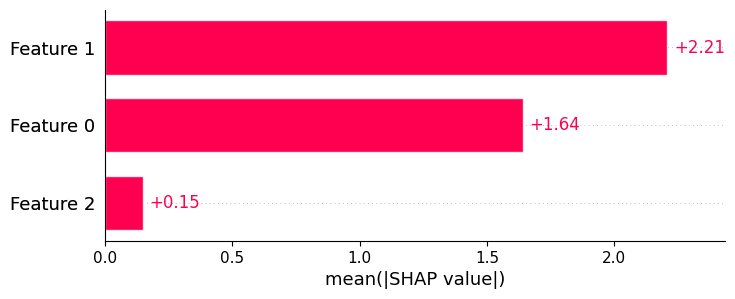

In [10]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X[:5])
shap.plots.bar(shap_values)

### $Saliency\ Map$
- **Math notation**: For input $x\in\mathbb{R}^d$ and output $y=M(x)$,
  $$R_i = \frac{\partial y}{\partial x_i},\quad i=1,\dots,d.$$


In [11]:
import torch
from torchvision import models

net = models.resnet18(pretrained=True).eval()
img = torch.randn(1,3,224,224, requires_grad=True)
out = net(img)[0,0]
out.backward()
saliency = img.grad.abs().max(dim=1)[0]  # shape (1,224,224)
print(saliency.shape)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


torch.Size([1, 224, 224])


### $SmoothGrad$
- **Math notation**: Average gradients over noisy inputs:
  $$\hat R_i = \frac{1}{N}\sum_{j=1}^N \frac{\partial M(x + \epsilon_j)}{\partial x_i},\quad \epsilon_j\sim \mathcal{N}(0,\sigma^2)$$


In [12]:
import numpy as np

def compute_gradient(model, x):
    # placeholder: compute and return gradient w.r.t. x
    pass

def smooth_grad(model, x, N=50, sigma=0.1):
    grads = []
    for _ in range(N):
        noise = x + np.random.normal(0, sigma, x.shape)
        grad = compute_gradient(model, noise)
        grads.append(grad)
    return np.mean(grads, axis=0)

### $Integrated\ Gradients$
- **Math notation**: For baseline $x'$,
  $$IG_i(x) = (x_i - x'_i)\int_{0}^{1} \frac{\partial M\bigl(x' + \alpha(x - x')\bigr)}{\partial x_i}\,d\alpha.$$


In [13]:
# Cell 16: Code
def integrated_gradients(model, x, x_baseline, steps=50):
    scaled_inputs = [x_baseline + (float(k)/steps)*(x-x_baseline) for k in range(steps+1)]
    grads = [compute_gradient(model, xi) for xi in scaled_inputs]
    avg_grads = np.mean(grads, axis=0)
    return (x - x_baseline) * avg_grads

### $LIME$
- **Math notation**: Fit an interpretable surrogate $g\in G$ by minimizing:
  $$\arg\min_{g\in G} \; L\bigl(f, g, \pi_x\bigr) + \Omega(g)$$


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X, feature_names=['f1','f2','f3'])
exp = explainer.explain_instance(X[0], model.predict, num_features=3)
print(exp.as_map())


### $SHAP$
- **Math notation**: Shapley value for feature $i$:
  $$\phi_i = \sum_{S\subseteq N\setminus\{i\}} \frac{|S|!\,(|N|-|S|-1)!}{|N|!}\bigl[f(S\cup\{i\}) - f(S)\bigr].$$


In [15]:
import shap
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X[:1])
print(shap_vals)

[[-2.29081226  2.11224997  0.14598434]]


### $Concept\ Activation\ Vector\ (TCAV)$
- **Math notation**: Directional derivative along concept vector $v_C$ for neuron $k$:
  $$S^C_k(x) = \nabla h_k(x) \cdot v_C$$


In [ ]:
# assume h(x) gives activations, and v_C computed via logistic regression
grad = compute_gradient(lambda inp: h(inp)[k], x)
tcav_score = np.dot(grad.flatten(), v_C.flatten())
print("TCAV score:", tcav_score)

### $Attention\ Mechanism$
- **Math notation**:
  $$\text{Attention}(Q,K,V) = \operatorname{softmax}\!\Bigl(\tfrac{QK^\top}{\sqrt{d_k}}\Bigr)\,V.$$

In [17]:
import torch.nn as nn
import torch

attn = nn.MultiheadAttention(embed_dim=64, num_heads=8)
query = key = value = torch.randn(10, 1, 64)
out, weights = attn(query, key, value)
print(weights.shape)  # (1,8,10,10)


torch.Size([1, 10, 10])


### $Prototype\ Network$
- **Math notation**: Class probability via prototype distances:
  $$p_c(x) \propto \exp\!\Bigl(-\min_j \|f(x) - p_{c,j}\|_2\Bigr).$$


In [18]:
import torch.nn.functional as F
# feats: (batch, dim); prototypes: (n_proto, dim)
def prototype_logits(feats, prototypes):
    dists = ((feats.unsqueeze(1) - prototypes)**2).sum(-1)  # (batch, n_proto)
    return -dists


### $Faithfulness$
- **Math notation**: Correlation between explanation scores $\phi_i$ and output change:
  $$\text{Faithfulness} = \mathrm{Corr}\bigl(\{\phi_i\}, \{\Delta M_i(x)\}\bigr).$$


In [ ]:
import numpy as np
# phi: attribution vector; delta: change in model output when removing feature i
faithfulness = np.corrcoef(phi, delta)[0,1]
print("Faithfulness:", faithfulness)


### $Stability$
- **Math notation**: Expected difference in explanations under input perturbations $\delta$:
  $$\text{Stability} = \mathbb{E}_{\|\delta\|\le\epsilon}\bigl\|E(M,x)-E(M,x+\delta)\bigr\|.$$


In [ ]:
deltas = [np.random.normal(0, 0.01, X[0].shape) for _ in range(20)]
exps = [explain(model, X[0]+δ) for δ in deltas]
stability = np.mean([np.linalg.norm(exps[0]-e) for e in exps])
print("Stability:", stability)

## **Demonstration with Breast Cancer Dataset**

We will utilize the UIC breat cancer data set for a demonstration.

All interpretability technique operate by transforming or probing the original input data in a different way—whether by reading off tree splits, perturbing inputs, computing gradients, fitting surrogates, or mapping the results to human recognizable concepts—so as to shed light on how the model processes that data.

Specifically:

Each method transforms or probes the original data $X$ (and its hidden representations) in a distinct way— such as
  - perturbation,
  -  gradient,
  - surrogate fitting, or
  - concept projection—
  
to reveal how the model uses features to arrive at predictions.  

---
* We start with loading the UCI Breast Cancer dataset:

  - X is an (n_samples × n_features) matrix of real‐valued tumor measurements (mean radius, texture, etc.).

  - y is a binary label (benign vs. malignant).

* We, then, split it into X_train, X_test (and y_train, y_test) so that about 75% of the samples train the models and 25% are held out for evaluation and explanations.


## 1. Data Loading & Splitting

- **Dataset**: UCI Breast Cancer  
- **Inputs**:  
  - $X\in\mathbb{R}^{n\times d}$, where $d=30$ features (e.g.\ mean radius, texture, etc.)  
  - $y\in\{0,1\}^n$ (benign vs.\ malignant labels)  
- **Split**:  
  - Training set $(X_{\text{train}}, y_{\text{train}})$ with $\approx75\%$ of samples  
  - Test set $(X_{\text{test}}, y_{\text{test}})$ with $\approx25\%$ of samples  

---

## 2. Model Training

We will use a Decition Tree, an MLP, and a Random Forest Model and compare results

**Decision Tree (dt)**

  - Learns a small tree of axis-aligned splits on individual features.

  -Because its structure is shallow (max_depth=3), you can literally read off which feature thresholds drive each classification decision.

**MLP Neural Net (mlp)**

  - A two-layer feed-forward network that transforms the raw 30-dimensional input via a hidden layer (16 units) into a single sigmoid output.

  _This is our “black box” whose internal decision surface is opaque without further tools.

**Random Forest (rf)**

  - An ensemble of 50 decision-tree estimators. We use this both to illustrate global feature importance (via mean decrease in impurity) and to apply model-agnostic explainers (LIME/SHAP).


1. **Decision Tree** ($dt$):  
   - Learns axis-aligned splits on features, up to depth $3$.  
2. **MLP Neural Net** ($mlp$):  
   - Two layers: $f(x)=\sigma(W_2\;\mathrm{ReLU}(W_1x))$, where $W_1\in\mathbb{R}^{16\times 30}$, $W_2\in\mathbb{R}^{1\times16}$.  
3. **Random Forest** ($rf$):  
   - Ensemble of $50$ trees; used for both global importance and model-agnostic explainers.

---

## 3. Global Interpretability

The decision tree model and Random Forest model would have global interpretability

Printing `export_text(dt, feature_names)` from decision tree would show exactly which features and thresholds appear at each split node—giving a holistic, white-box view of what the tree deems most predictive.

`rf.feature_importances_` will give a single importance score per feature, averaged over all trees in the forest. Higher means that feature more strongly reduces impurity/heterogeneity across the ensemble.

- **Decision Tree Export**:  
  - You read off the exact feature thresholds in each node.  
- **RF Feature Importances**:  
  - $\text{Imp}_i = \tfrac{1}{T}\sum_{t=1}^T \Delta\mathrm{Impurity}_i^{(t)}$, averaged over trees $t=1,\dots,T$.

---

## 4. Local Interpretability (LIME)

For this example we picked one held-out test sample designated `X_test[0]`.

- LIME generates many perturbed versions of that sample by randomly turning features “on” or “off” (or slightly jittering them), then queries the RF’s predict_proba on each perturbed sample.

- It fits a simple surrogate (linear) model to those perturbation–prediction pairs, and reports the top‐k features whose changes most affect the RF’s probability output for that instance.

- **Instance**: $x_0 = X_{\text{test}}[0]$  
- **Perturbations**: Generate $\{\tilde x_j\}$ by randomly jittering features.  
- **Surrogate**: Fit linear model $g(z)=w^\top z + b$ minimizing  
  $$\min_{w,b}\sum_j \pi(x_0,\tilde x_j)\,\bigl(f(\tilde x_j)-g(\tilde x_j)\bigr)^2 + \Omega(w)\,,$$  
  where $\pi$ weights proximity to $x_0$.

---

## 5. Gradient-based Attributions (Saliency, SmoothGrad, Integrated Gradients)

- **Saliency**

  - We compute ∂output/∂input for our one sample. Features with larger absolute gradient values are ones where a small change in that feature would most change the network’s output.

- **SmoothGrad**

  - We average those gradients over 50 noisy copies of the input, which reduces visual noise and highlights consistently important features.

- **Integrated Gradients**

  -We integrate the gradients along a straight path from a “baseline” (all-zero) input to our actual sample. That path‐integral attributes importance in a way satisfying certain axioms (e.g. sensitivity).

1. **Saliency**:  
   $$R_i = \frac{\partial f(x_0)}{\partial x_{0,i}}\,. $$
2. **SmoothGrad**:  
   $$\hat R_i = \frac{1}{N}\sum_{j=1}^N \frac{\partial f(x_0 + \epsilon_j)}{\partial x_i},\quad \epsilon_j\sim\mathcal{N}(0,\sigma^2).$$
3. **Integrated Gradients**:  
   $$\mathrm{IG}_i = (x_{0,i}-x'_i)\int_{0}^{1}\frac{\partial f\bigl(x' + \alpha(x_0-x')\bigr)}{\partial x_i}\,d\alpha\,, $$  
   with baseline $x'$ (all zeros).

---

## 6. SHAP (TreeExplainer on RF)

Shapley values quantify each feature’s contribution by considering all possible “coalitions” of features.

For our sample, `shap_values[i]` tells us how much feature i added (or subtracted) to the RF’s log‐odds of predicting malignant vs. benign.

- **Shapley Value** for feature $i$:  
  $$\phi_i = \sum_{S\subseteq N\setminus\{i\}}\frac{|S|!\,(|N|-|S|-1)!}{|N|!}\,\bigl[f(S\cup\{i\}) - f(S)\bigr].$$

---

## 7. Concept Activation Vector (TCAV)

- We first define a human concept: **“high mean radius”**.

- We split training samples into those above vs. below the median radius, pass them into the MLP’s first hidden layer, and fit a linear classifier there. The resulting weight vector $v_C$ points in the hidden‐layer direction that best separates “high” vs. “low” radius.

- Taking the directional derivative of the network’s hidden representation along $v_C$ on our test input gives a scalar TCAV score, measuring how sensitive the model is to that concept.

1. **Concept**: “High mean radius” $\Rightarrow$ split $X_{\text{train}}$ by median of feature 0.  
2. **CAV**: Fit linear classifier in hidden layer $h(x)=W_1x$ to get vector $v_C$.  
3. **TCAV Score**:  
   $$S^C(x_0) = \nabla_{h}\,f(x_0)\;\cdot\;v_C\,. $$

---

## 8. Attention Mechanism

- We treat the 30 features of our one test sample as a “sequence” of length 30, each embedded in 30-dim space.

- A tiny self-attention layer computes pairwise attention weights, showing which features “pay attention” to which others when producing a new representation.


- Treat features as a sequence of length $d$:  
  $$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\Bigl(\tfrac{QK^\top}{\sqrt{d_k}}\Bigr)V\,, $$  
  where $Q=K=V=\text{embedded input}$.

---

## 9. Prototype Network
- We pass all training samples through the MLP’s first hidden layer to get 16-dim embeddings.

- We compute the mean embedding for each class (benign vs. malignant)—those are our prototypes.

- For a test point, we compute Euclidean distances to each prototype; smaller distance implies stronger similarity to that class’s prototype.

1. Compute embeddings $h_i = W_1 x_i$ for all $i\in\text{train}$.  
2. Prototypes:  
   $$p_c = \frac{1}{|\mathcal{I}_c|}\sum_{i\in \mathcal{I}_c} h_i,\quad c\in\{\text{benign, malignant}\}.$$
3. Distances for test $x_0$:  
   $$d_c = \|h_0 - p_c\|_2\,, $$  
   smaller $d_c$ means stronger similarity to class $c$.

---

## 10. Faithfulness & Stability
- Zeroing out the top-k IG-attributed features should drop the model’s output by an amount correlated with the IG scores. We compute a correlation as a quantitative “faithfulness” measure.

-  We add small Gaussian noise to the same test instance many times, rerun LIME each time, and measure how much the explanation vectors vary. Smaller average norm difference means more stable explanations.


- **Faithfulness (IG)**: Correlate $\{\mathrm{IG}_i\}$ with output drop when zeroing top-$k$ features.  
- **Stability (LIME)**:  
  $$\mathbb{E}_{\|\delta\|\le\epsilon}\bigl\|E(x_0)-E(x_0+\delta)\bigr\|\,, $$  
  average LIME-explanation difference under small noise $\delta$.

---


# 1. Load Data and Train Models

We’ll use the sklearn breast-cancer dataset.
- **Intrinsic model**: Decision Tree  
- **Black-box model**: Simple 2-layer MLP  
- **Ensemble**: Random Forest (for global feature importance & SHAP/LIME)

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np

# 1) Load & split
X, y = load_breast_cancer(return_X_y=True)
feature_names = load_breast_cancer().feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# 2) Intrinsic: Decision Tree
dt = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)

# 3) Black-box: MLP
class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d, 16)
        self.fc2 = nn.Linear(16, 1)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x))
mlp = MLP(X.shape[1])
opt = torch.optim.Adam(mlp.parameters(), lr=1e-2)
# train briefly
for _ in range(200):
    opt.zero_grad()
    pred = mlp(torch.from_numpy(X_train).float()).squeeze()
    loss = F.binary_cross_entropy(pred, torch.from_numpy(y_train).float())
    loss.backward(); opt.step()

# 4) Ensemble
rf = RandomForestClassifier(n_estimators=50).fit(X_train, y_train)


# 2. Global Interpretability  
**Decision Tree** (intrinsic) and **Random Forest** feature importances  


In [22]:
# Decision tree textual export
print(export_text(dt, feature_names=feature_names))

# RF global importances
print("RF importances:\n", list(zip(feature_names, rf.feature_importances_)))


|--- mean concave points <= 0.05
|   |--- worst radius <= 17.59
|   |   |--- area error <= 42.19
|   |   |   |--- class: 1
|   |   |--- area error >  42.19
|   |   |   |--- class: 0
|   |--- worst radius >  17.59
|   |   |--- worst texture <= 26.01
|   |   |   |--- class: 1
|   |   |--- worst texture >  26.01
|   |   |   |--- class: 0
|--- mean concave points >  0.05
|   |--- worst area <= 785.80
|   |   |--- worst texture <= 23.74
|   |   |   |--- class: 1
|   |   |--- worst texture >  23.74
|   |   |   |--- class: 0
|   |--- worst area >  785.80
|   |   |--- radius error <= 0.19
|   |   |   |--- class: 1
|   |   |--- radius error >  0.19
|   |   |   |--- class: 0

RF importances:
 [(np.str_('mean radius'), np.float64(0.056141345764387764)), (np.str_('mean texture'), np.float64(0.011564512548914116)), (np.str_('mean perimeter'), np.float64(0.03698713247701278)), (np.str_('mean area'), np.float64(0.021464939755431987)), (np.str_('mean smoothness'), np.float64(0.00791502420554649)), (np

# 3. Local Interpretability  
Use **LIME** to explain one test instance from the RF  


In [23]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X_train, feature_names=feature_names, class_names=['benign','malig'], verbose=False)
exp = explainer.explain_instance(X_test[0], rf.predict_proba, num_features=5)
print("LIME local explanation:\n", exp.as_list())


LIME local explanation:
 [('worst concave points > 0.16', -0.07396295692787563), ('mean concave points > 0.08', -0.07102970547312225), ('worst texture > 29.41', -0.059192406996052487), ('worst compactness > 0.34', -0.053283508693703054), ('worst concavity > 0.38', -0.04588151107228962)]


# 4. Post-hoc Deep Attribution (Saliency, SmoothGrad, Integrated Gradients)  
We’ll use Captum on our MLP.


In [25]:
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21

In [24]:
from captum.attr import Saliency, IntegratedGradients, NoiseTunnel
mlp.eval()
inp = torch.from_numpy(X_test[:1]).float().requires_grad_()

# 4a) Saliency
sal = Saliency(mlp)
sal_attr = sal.attribute(inp).detach().numpy().squeeze()

# 4b) SmoothGrad
nt = NoiseTunnel(sal)
smooth_attr = nt.attribute(inp, nt_type='smoothgrad', stdevs=0.1, nt_samples=50).detach().numpy().squeeze()

# 4c) Integrated Gradients
ig = IntegratedGradients(mlp)
ig_attr = ig.attribute(inp, baselines=torch.zeros_like(inp), n_steps=50).detach().numpy().squeeze()

print("Saliency:", sal_attr)
print("SmoothGrad:", smooth_attr)
print("Integrated Gradients:", ig_attr)


ModuleNotFoundError: No module named 'captum'

# 5. SHAP  
Use TreeExplainer on the RF for one instance  


In [ ]:
import shap
shap_explainer = shap.TreeExplainer(rf)
shap_values = shap_explainer.shap_values(X_test[:1])[1]
print("SHAP values:", list(zip(feature_names, shap_values)))


# 6. Concept Activation Vector (TCAV)  
Define a “high mean radius” concept and see how sensitive the MLP is to it.


In [ ]:
# 6a) Build concept examples: indices where feature[0] (mean radius) > median
median_radius = np.median(X_train[:,0])
C_pos = X_train[X_train[:,0]>median_radius]
C_neg = X_train[X_train[:,0]<=median_radius]

# 6b) Fit linear boundary in MLP’s hidden layer to get v_C
with torch.no_grad():
    h_pos = mlp.fc1(torch.from_numpy(C_pos).float())
    h_neg = mlp.fc1(torch.from_numpy(C_neg).float())
from sklearn.linear_model import LogisticRegression
v_C = LogisticRegression().fit(np.vstack([h_pos.numpy(),h_neg.numpy()]),
                              [1]*len(h_pos)+[0]*len(h_neg)).coef_.reshape(-1)

# 6c) TCAV directional derivative
inp_h = mlp.fc1(inp).detach().numpy().squeeze()
grad_h = Saliency(lambda x: mlp.fc1(x)).attribute(inp).detach().numpy().squeeze()
tcav_score = np.dot(grad_h, v_C)
print("TCAV score (mean-radius):", tcav_score)


# 7. Attention Mechanism Example  
A tiny self-attention over the feature vector (treated as “sequence” of length d).


In [ ]:
import torch.nn as nn
attn = nn.MultiheadAttention(embed_dim=X.shape[1], num_heads=2, batch_first=True)
# reshape X_test[0] → (batch=1, seq_len=d, embed=d)
seq = torch.from_numpy(X_test[:1]).float().unsqueeze(2)  # (1,d,1)
seq = seq.repeat(1,1,X.shape[1])                      # (1,d,d)
out, weights = attn(seq, seq, seq)
print("Attention weights shape:", weights.shape)  # (1,2,d,d)


# 8. Prototype Network  
Learn a prototype for each class in the MLP’s latent space.


In [26]:
# Compute MLP embedding for all train samples
with torch.no_grad():
    H = mlp.fc1(torch.from_numpy(X_train).float()).numpy()
proto_benign = H[y_train==0].mean(axis=0)
proto_malig  = H[y_train==1].mean(axis=0)

# For a test point:
h_test = mlp.fc1(torch.from_numpy(X_test[:1]).float()).detach().numpy().squeeze()
d0 = np.linalg.norm(h_test - proto_benign)
d1 = np.linalg.norm(h_test - proto_malig)
print("Prototype distances → benign:", d0, "malignant:", d1)


Prototype distances → benign: 398.76837 malignant: 166.48311


# 9. Faithfulness & Stability  
Compute how well IG attributions predict output change (faithfulness), and how stable LIME is under small noise.


In [ ]:
# 9a) Faithfulness: correlate IG vs. output drop when zeroing top‐k features
ig_scores = ig_attr
top_idx = np.argsort(-np.abs(ig_scores))[:3]
X_pert = X_test[:1].copy()
X_pert[0, top_idx] = 0
orig = mlp(torch.from_numpy(X_test[:1]).float()).item()
new  = mlp(torch.from_numpy(X_pert).float()).item()
delta = orig - new
faithfulness = np.corrcoef(ig_scores, [delta]*len(ig_scores))[0,1]
print("Faithfulness (IG):", faithfulness)

# 9b) Stability: variance of LIME explanations under noise
lime_scores = np.array([dict(exp.as_list()).get(fn,0) for fn in feature_names])
stabilities = []
for _ in range(20):
    noise = X_test[0] + np.random.normal(0,0.01,X.shape[1])
    exp_n = explainer.explain_instance(noise, rf.predict_proba, num_features=5)
    scores_n = np.array([dict(exp_n.as_list()).get(fn,0) for fn in feature_names])
    stabilities.append(np.linalg.norm(lime_scores - scores_n))
print("Avg LIME stability:", np.mean(stabilities))
